# 08_export_results · Coco's scenarios → pool projection → shared results

**Purpose.** Run the collateral model on the team's official scenarios (Coco's `data/scenarios/scenarios.csv`) and produce everything teammates use: the monthly pool cash flows for Smarajit's waterfall, the summary tables and the figures. It also covers the few functions the other notebooks don't call directly.

**Process.**
1. **Load the scenarios** with `load_scenarios` / `get_scenarios` and check them.
2. **Plot the paths**: mortgage rate, home prices, and the SOFR coupon index from `pricing_rates.csv`.
3. **Look at `pricing_rates.csv`**, the discounting and coupon inputs Smarajit needs.
4. **One month by hand** with `calculate_credit_events` and `calculate_prepayment`, the building blocks inside `project_collateral`.
5. **Project the pool** under each scenario with `project_collateral` / `run_scenarios`.
6. **Compare** Coco's scenarios with the earlier interim paths.
7. **Export** CSV tables and figures with `src/export_results.py`.
8. **The `collateral.py` wrapper** and two calibration helpers (`default_buckets`, `pipeline_outcomes`) not called directly elsewhere.

Scenarios are generated by Coco's code: `/opt/anaconda3/envs/XCS231N/bin/python -m src.scenarios --download` (your default Python 3.14 crashes on its date handling). This notebook itself runs in your normal Jupyter.

**What this code does.** Finds the repo root, imports the model modules, loads the STACR pool with `load_pool()` (the August tape rolled forward to the post-September balance) and checks whether Coco's `scenarios.csv` is in `data/scenarios/`.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.4f}".format)

from src import collateral_projection as cp, prepayment as pp, credit_model as cm
pool = cp.load_pool()   # post-September 2026 pool: the August tape rolled forward one month
print(f"tape as of {pool.attrs['tape_as_of']}, rolled forward {pool.attrs['rolled_forward_months']} month(s)")
print(f"pool: {len(pool):,} loans, ${pool['Current Balance'].sum()/1e9:.2f}bn | scenario file: {cp.SCENARIO_CSV.relative_to(ROOT)}, exists = {cp.SCENARIO_CSV.exists()}")

tape as of 2026-08, rolled forward 1 month(s)
pool: 56,871 loans, $19.25bn | scenario file: data/scenarios/scenarios.csv, exists = True


**Result · Setup.** The pool has **56,871 loans, $19.25bn** after rolling the August tape forward to the post-September balance, and Coco's `data/scenarios/scenarios.csv` exists, so every step below uses her official paths.

---
## 1 · Load Coco's scenarios: `load_scenarios` / `get_scenarios`

**What this code does.** Reads Coco's CSV as a plain table to see exactly what she delivered: columns, months per scenario, and the first and last rows.

In [2]:
raw = pd.read_csv(cp.SCENARIO_CSV)
print(f"{len(raw)} rows, columns: {list(raw.columns)}")
print(raw.groupby("scenario", sort=False)["month"].agg(["min", "max", "count"]))
raw[raw.month.isin([0, 1, 2, 53])][["scenario", "month", "date", "mortgage_rate", "hpi_index", "sofr"]]

216 rows, columns: ['scenario', 'month', 'date', 'mortgage_rate', 'hpi_index', 'sofr_overnight', 'treasury2', 'treasury10', 'mortgage_spread', 'sofr']
          min  max  count
scenario                 
good        0   53     54
base        0   53     54
moderate    0   53     54
severe      0   53     54


,scenario,month,date,mortgage_rate,hpi_index,sofr
0,good,0,2026-10-03,7.2800,100.0000,3.7612
1,good,1,2026-10-25,7.2245,100.3830,3.6903
2,good,2,2026-11-25,7.1776,100.8019,3.8803
53,good,53,2031-02-25,5.6652,132.1151,3.4371
54,base,0,2026-10-03,7.2800,100.0000,3.7612
55,base,1,2026-10-25,7.2276,100.3514,3.6903
56,base,2,2026-11-25,7.1783,100.7221,3.8801
107,base,53,2031-02-25,5.7855,122.2538,3.4238
108,moderate,0,2026-10-03,7.2800,100.0000,3.7612
109,moderate,1,2026-10-25,7.1530,100.5923,3.6903


**What the output shows.** 216 rows = 4 scenarios × months 0–53. Besides the required `mortgage_rate` and `hpi_index`, the file carries the date and Coco's rate factors (SOFR, 2- and 10-year Treasuries, mortgage spread). Month 0 is today (2026-10-03, PMMS 7.28%, HPI 100); month 1 is the first payment date, 2026-10-25; month 53 is the call date, 2031-02-25.

**What this code does.** Calls `get_scenarios()`, which uses `load_scenarios` on Coco's file (checking scenario names, months 0–53 with no gaps, matching dates ending on the call date, positive values) and returns, per scenario, the monthly mortgage rate for months 1–53 and HPI rescaled to 1.0 at month 0.

In [3]:
scen = cp.get_scenarios()                      # Coco's file when present, else interim paths
N = len(next(iter(scen.values()))["rate"])
summary = pd.DataFrame({k: {"months": len(v["rate"]), "rate m1": v["rate"][0], "rate m12": v["rate"][11],
                            "rate m53": v["rate"][-1], "min rate": v["rate"].min(),
                            "HPI m53": v["hpi"][-1], "min HPI": v["hpi"].min()} for k, v in scen.items()}).T
print("projection months:", N)
summary.round(3)

projection months: 53


,months,rate m1,rate m12,rate m53,min rate,HPI m53,min HPI
base,53.0000,7.2280,6.7370,5.7860,5.7860,1.2230,1.0000
good,53.0000,7.2250,6.7010,5.6650,5.6650,1.3210,1.0000
moderate,53.0000,7.1530,7.1430,5.8960,5.8180,0.8630,0.8620
severe,53.0000,7.3040,7.0940,5.3940,5.3490,0.7890,0.7870


**Result · Loaded scenarios.** All four scenarios have 53 projection months. Rates start near today's 7.28% and drift down in every path; HPI rises in good and base and falls in moderate and severe:

| | rate m1 | m12 | m53 | HPI m53 |
|---|---|---|---|---|
| good | 7.23 | 6.70 | **5.67** | **1.32** |
| base | 7.23 | 6.74 | **5.79** | **1.22** |
| moderate | 7.15 | 7.14 | **5.90** | **0.86** |
| severe | 7.30 | 7.09 | **5.39** | **0.79** |

**Q&A · Loading the scenarios**

**Q: What happens if Coco's file is missing or broken?**
A: If the file is missing, `get_scenarios` falls back to the interim paths built around today's PMMS. If it's present but broken (missing months, duplicate rows, unknown scenario names, dates that disagree or don't end on the call date, non-positive values), `load_scenarios` raises an error instead of silently projecting nonsense.

**Q: Why is HPI rescaled to 1.0 at month 0?**
A: The pool's HPI-adjusted LTVs are measured at today's prices. Rescaling makes "HPI = 1.0" mean "today", so mark-to-market LTV = tape LTV / HPI_t works whatever base Coco's index uses.

**Q: Why does the loader check dates as text?**
A: ISO dates like 2026-10-25 sort correctly as strings, and pandas' date parser crashes on this Mac's Python 3.14. String checks avoid the crash with the same validation.

---
## 2 · Plot the scenario paths

**What this code does.** Plots, by month, the mortgage rate (with the pool's WA coupon of 6.76% as a dashed line), home prices, and the 30-day SOFR coupon index from Coco's `pricing_rates.csv`.

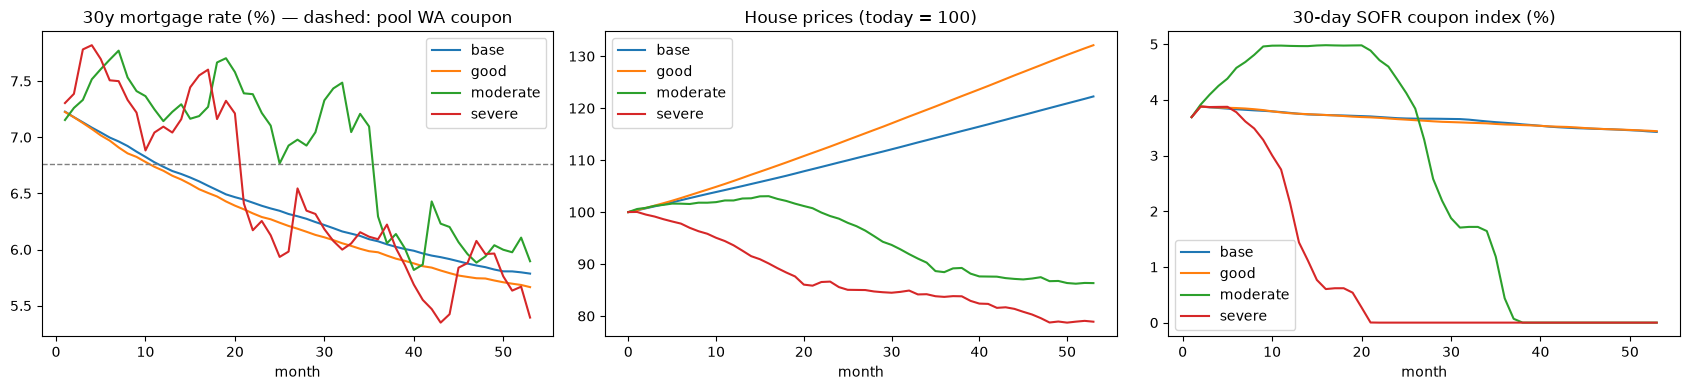

In [4]:
pr = pd.read_csv(ROOT / "data" / "scenarios" / "pricing_rates.csv")
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for name, s in scen.items():
    ax[0].plot(range(1, N + 1), s["rate"], label=name)
    ax[1].plot(range(N + 1), s["hpi"] * 100, label=name)
    g = pr[pr.scenario == name]; ax[2].plot(g.month, g.sofr_coupon_decimal * 100, label=name)
ax[0].axhline(pool["Gross Coupon"].mul(pool["Current Balance"]).sum() / pool["Current Balance"].sum(), color="grey", ls="--", lw=1)
ax[0].set_title("30y mortgage rate (%) — dashed: pool WA coupon"); ax[1].set_title("House prices (today = 100)")
ax[2].set_title("30-day SOFR coupon index (%)")
for a in ax: a.set_xlabel("month"); a.legend()
plt.tight_layout()

**Result · Scenario paths.** The mortgage rate starts **above** the pool's 6.76% coupon in every scenario (out of the money) and crosses below it after about a year in good and base, and between years 2 and 3 in moderate. Home prices fan out from +32% to −21%. SOFR stays around 3.4–3.9% in good and base but falls to **0%** in moderate and severe, because those replay 2006–2011, when the Fed cut rates to zero.

**Q&A · Scenario paths**

**Q: Why does the dashed coupon line matter?**
A: Prepayment depends on coupon − market rate. Above the line borrowers have no refinancing incentive (CPR ≈ turnover, 5–8%); below it they start refinancing. Where each scenario crosses the line drives the timing of the pool's paydown.

**Q: Why do moderate and severe rates fall but SOFR hit zero?**
A: They replay the 2006–2011 joint history of rates and house prices, re-anchored to today. In that period short rates fell to zero while mortgage rates fell more slowly. That matters for Smarajit: STACR coupons are SOFR + spread, so the notes' coupon income collapses in those scenarios.

---
## 3 · `pricing_rates.csv`: inputs for Smarajit's pricing

**What this code does.** Shows what `pricing_rates.csv` contains per scenario and month: payment date, SOFR reset date, accrual days, the projected SOFR coupon, and a cumulative discount factor.

In [5]:
print(f"{len(pr)} rows, columns: {list(pr.columns)}")
print(pr.groupby("scenario", sort=False).agg(first_coupon=("sofr_coupon_decimal", "first"), last_coupon=("sofr_coupon_decimal", "last"),
                                             final_discount_factor=("base_discount_factor", "last")).round(4))
pr[pr.scenario == "base"].head(3)

212 rows, columns: ['scenario', 'month', 'date', 'reset_date', 'accrual_start', 'coupon_accrual_days', 'discount_days', 'sofr_coupon_decimal', 'fixing_source', 'base_discount_factor', 'discount_basis']
          first_coupon  last_coupon  final_discount_factor
scenario                                                  
good            0.0369       0.0344                 0.8506
base            0.0369       0.0342                 0.8503
moderate        0.0369       0.0000                 0.8931
severe          0.0369       0.0000                 0.9651


,scenario,month,date,reset_date,accrual_start,coupon_accrual_days,discount_days,sofr_coupon_decimal,fixing_source,base_discount_factor,discount_basis
53,base,1,2026-10-25,2026-09-23,2026-09-25,30,22,0.0369,observed,0.9976,physical_scenario_overnight_no_credit_spread
54,base,2,2026-11-25,2026-10-22,2026-10-25,31,31,0.0388,projected,0.9943,physical_scenario_overnight_no_credit_spread
55,base,3,2026-12-25,2026-11-23,2026-11-25,30,30,0.0387,projected,0.9911,physical_scenario_overnight_no_credit_spread


**Result · Pricing inputs.** 212 rows (4 scenarios × 53 payment dates). Month 1 uses the already-published SOFR fixing (**3.69%**, "observed"); later months are projected. Month 1 discounts only **22 days** (Oct 3 → Oct 25). Final discount factors at the 2031 call are **0.850** (good), **0.850** (base), **0.893** (moderate) and **0.965** (severe), higher where SOFR falls to zero.

**Q&A · Pricing inputs**

**Q: Which file does Smarajit use for what?**
A: Cash flows come from this model (`outputs/tables/pool_cf_<scenario>.csv`), passed through his waterfall. Coupons (SOFR + each class's spread) and discount factors come from Coco's `pricing_rates.csv`, matched by scenario and month.

**Q: What does "physical_scenario_overnight_no_credit_spread" mean?**
A: Discounting uses the scenario's own SOFR path, with no added credit spread and under real-world (not risk-neutral) assumptions. To get a price or discount margin, Smarajit adds the tranche's spread or solves for it on top of these factors.

---
## 4 · One month by hand: `calculate_credit_events` and `calculate_prepayment`

The same four steps `project_collateral` runs each month, on the real pool for month 1 of the base scenario.

**What this code does.** Runs month 1 of the base scenario by hand on the whole pool: default probability → `calculate_credit_events` (MDR × performing balance) → remove the liquidating share → scheduled principal → `calculate_smm` and `calculate_prepayment` (SMM × balance after scheduled principal). It then compares with `project_collateral`'s month 1.

In [6]:
base = scen["base"]
perf = pool["Current Balance"].to_numpy()                                       # performing balance
mdr = cm.calculate_credit_event_rate(pool, base["hpi"][:2])[:, 0]              # month-1 default probability
new_defaults = cm.calculate_credit_events(perf, mdr)                            # MDR x performing balance
after = perf - (1 - cm.PARAMS["mod_share"]) * new_defaults                      # liquidation share leaves
sched = cp.scheduled_principal(after, pool["Gross Coupon"].to_numpy(), pool["Months to Maturity"].to_numpy())
smm = pp.calculate_smm(pp.calculate_cpr(pool, base["rate"][:1])[:, 0])
prepaid = pp.calculate_prepayment(after, sched, smm)                            # SMM x (balance - scheduled)
print(f"new default spells:      ${new_defaults.sum()/1e6:8.2f}mm  (rate {new_defaults.sum()/perf.sum()*1200:.2f}% a year)")
print(f"scheduled principal:     ${sched.sum()/1e6:8.2f}mm")
print(f"prepayments:             ${prepaid.sum()/1e6:8.2f}mm  (CPR {pp.smm_to_cpr(prepaid.sum()/(after-sched).sum()):.1%})")
cf1 = cp.project_collateral(pool, base["hpi"], base["rate"], N).iloc[0]
print(f"project_collateral month 1: scheduled ${cf1.scheduled_principal/1e6:.2f}mm, prepayments ${cf1.prepayments/1e6:.2f}mm")

new default spells:      $    7.44mm  (rate 0.46% a year)
scheduled principal:     $   18.75mm
prepayments:             $  143.25mm  (CPR 8.6%)


project_collateral month 1: scheduled $18.71mm, prepayments $142.83mm

**Result · One month by hand.** New default spells **$7.4mm** (0.46% a year), scheduled principal **$18.8mm**, prepayments **$143.3mm** (8.6% CPR). `project_collateral` gives $18.7mm and **$142.8mm**. The small gap is expected: the full model starts the 60+ day delinquent and B/F loans (about $48mm) in the liquidation pipeline rather than the performing balance.

**Q&A · One month by hand**

**Q: Why apply defaults before scheduled principal and prepayment?**
A: A loan that defaults this month doesn't also pay its scheduled principal or prepay. Removing defaults first, then computing scheduled principal on what's left, then applying SMM to the balance after scheduled principal means no dollar leaves twice.

**Q: Why is the month-1 CPR only 8.6%?**
A: In month 1 the base mortgage rate is 7.23%, above the pool's 6.76% average coupon, so refinancing isn't worthwhile for most borrowers and speeds sit near turnover.

---
## 5 · Project the pool: `project_collateral` / `run_scenarios`

**What this code does.** Runs `run_scenarios`, which calls `project_collateral` for each of Coco's four paths over 53 months, and summarizes CPR in years 1 and 4, end balance, credit events, losses and the balance-identity error.

In [7]:
res = cp.run_scenarios(pool, scen, N)
rows = {}
for name, df in res.items():
    smm_m = (df.prepayments / (df.beginning_balance - df.scheduled_principal)).to_numpy()
    rows[name] = {"CPR yr1 %": pp.smm_to_cpr(smm_m[:12]).mean() * 100, "CPR yr4 %": pp.smm_to_cpr(smm_m[36:48]).mean() * 100,
                  "end balance $bn": df.ending_balance.iloc[-1] / 1e9, "credit events $mm": df.defaults.sum() / 1e6,
                  "losses $mm": df.losses.sum() / 1e6, "loss % cut-off": df.losses.sum() / cp.CUTOFF_BALANCE * 100,
                  "avg severity %": df.losses.sum() / df.defaults.sum() * 100,
                  "max identity error $": (df.beginning_balance - df.scheduled_principal - df.prepayments - df.defaults - df.ending_balance).abs().max()}
proj = pd.DataFrame(rows).T
proj.round(3)

,CPR yr1 %,CPR yr4 %,end balance $bn,credit events $mm,losses $mm,loss % cut-off,avg severity %,max identity error $
base,10.5910,23.4650,7.3290,116.7870,47.2680,0.2070,40.4740,0.0000
good,10.9330,25.1500,6.8210,114.5980,43.4330,0.1910,37.9010,0.0000
moderate,7.5890,24.1990,9.3010,128.7170,65.2050,0.2860,50.6580,0.0000
severe,7.9940,26.7770,7.1630,142.0140,80.7590,0.3540,56.8670,0.0000


**Result · Projection.** The balance identity holds to **$0.00** in every scenario.

| | CPR yr 1 | CPR yr 4 | end balance | losses | % of cut-off | severity |
|---|---|---|---|---|---|---|
| good | 10.9% | 25.2% | $6.82bn | $43.4mm | **0.191%** | 37.9% |
| base | 10.6% | 23.5% | $7.33bn | $47.3mm | **0.207%** | 40.5% |
| moderate | 7.6% | 24.2% | $9.30bn | $65.2mm | **0.286%** | 50.7% |
| severe | 8.0% | 26.8% | $7.16bn | $80.8mm | **0.354%** | 56.9% |

Prepayment is slow in year 1 and about 2.5× faster by year 4 as rates fall. Losses rise from good to severe mainly through severity (38% → 57%) and somewhat through more credit events ($115mm → $142mm).

**What this code does.** Plots each scenario's pool balance and cumulative loss as % of the cut-off balance, with the B-3H/B-2H (0.25%) and B-2H/B-1H (1.45%) boundaries.

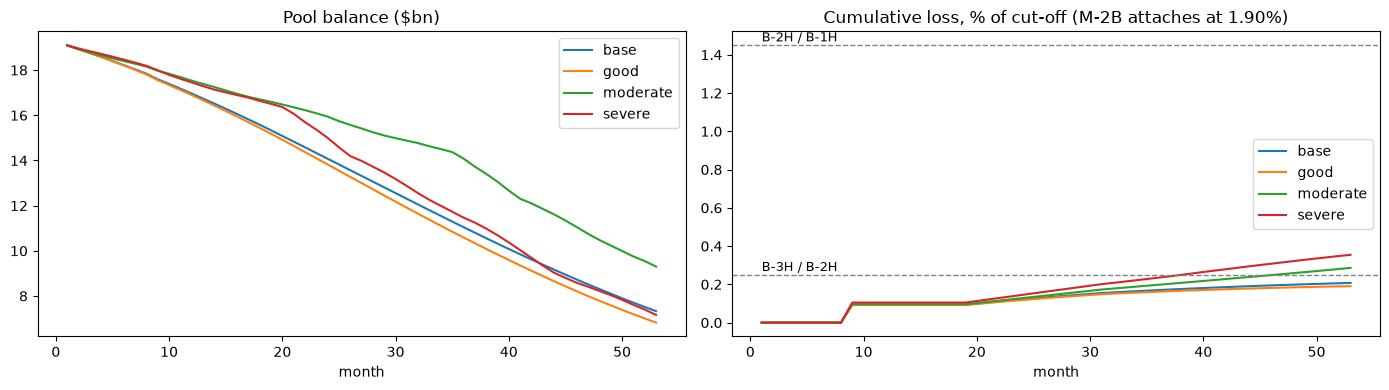

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for name, df in res.items():
    ax[0].plot(df.month, df.ending_balance / 1e9, label=name)
    ax[1].plot(df.month, df.losses.cumsum() / cp.CUTOFF_BALANCE * 100, label=name)
for lvl, lab in [(0.25, "B-3H / B-2H"), (1.45, "B-2H / B-1H")]:
    ax[1].axhline(lvl, color="grey", ls="--", lw=1); ax[1].text(1, lvl + 0.02, lab, fontsize=9)
ax[0].set_title("Pool balance ($bn)"); ax[1].set_title("Cumulative loss, % of cut-off (M-2B attaches at 1.90%)")
for a in ax: a.set_xlabel("month"); a.legend()
plt.tight_layout()

**Result · Balance and losses chart.** Balances fall slowly for two years, then faster as rates drop. Cumulative losses jump in month 9 (the tape's seriously delinquent loans liquidating), then climb steadily from month 20. Good and base stay under the **0.25%** line (inside B-3H); moderate and severe cross it into **B-2H**, and every path stays far below 1.45% and the 1.90% where M-2B starts.

**Q&A · Projection**

**Q: Why do losses step up in month 9?**
A: About $48mm of loans were already 60+ days late or in bankruptcy/foreclosure on the tape. The model assumes they're halfway through the 19-month liquidation lag, so they liquidate in month 9 with about $21–24mm of loss in every scenario.

**Q: Which tranches take losses?**
A: B-3H (0–0.25% of cut-off) in all scenarios, fully used in moderate and severe; B-2H (0.25–1.45%) takes about $8mm in moderate and $24mm in severe. B-1H and the offered M-2B, M-1 and A-1 take nothing.

**Q: What's the main risk for the offered notes, then?**
A: Timing. They're protected by 1.90% of subordination, about 5× the severe loss, but slow early prepayment extends them, and falling SOFR in the stress paths cuts their coupon.

---
## 6 · Coco's scenarios vs the interim paths

**What this code does.** Reruns the projection on the interim placeholder paths (flat rates around today's 7.28%) and compares end balances and losses with Coco's scenarios.

In [9]:
interim = cp.run_scenarios(pool, cp.placeholder_scenarios(N), N)
cmp_ = pd.DataFrame({name: {"Coco end bal $bn": res[name].ending_balance.iloc[-1] / 1e9,
                            "interim end bal $bn": interim[name].ending_balance.iloc[-1] / 1e9,
                            "Coco loss %": res[name].losses.sum() / cp.CUTOFF_BALANCE * 100,
                            "interim loss %": interim[name].losses.sum() / cp.CUTOFF_BALANCE * 100} for name in res}).T
cmp_.round(3)

,Coco end bal $bn,interim end bal $bn,Coco loss %,interim loss %
base,7.3290,12.5120,0.2070,0.2340
good,6.8210,7.4470,0.1910,0.1920
moderate,9.3010,11.6130,0.2860,0.2890
severe,7.1630,10.4120,0.3540,0.3420


**Result · Coco vs interim.** Losses are almost the same (good 0.191% vs 0.192%, base **0.207% vs 0.234%**, moderate 0.286% vs 0.289%, severe **0.354% vs 0.342%**). End balances differ a lot: **$7.33bn vs $12.51bn** in base, because Coco's rates fall toward about 5.8% while the interim base stayed flat at 7.28%.

**Q&A · Coco vs interim**

**Q: Why are losses similar but balances so different?**
A: Most defaults that liquidate before 2031 happen in the first 2–3 years, when both sets of paths have rates near 7%. The balance difference builds later, when Coco's rates fall and prepayment picks up.

**Q: Why are base losses lower with Coco's paths?**
A: Her base has stronger home prices (+22% vs +13%) and lets loans pay off in years 3–4 before they can default.

---
## 7 · Export the shared results: `src/export_results.py`

Writes CSV tables to `outputs/tables/` and every notebook chart to `outputs/figures/`. `calibration_tables` refits on the Freddie data (about 30 seconds), so it runs only if the panels exist.

**What this code does.** Runs the parts of `src/export_results.py` one by one: scenario tables (pool cash flows, summary, paths used), the fitted parameter table, the calibration tables (refits on the Freddie data), and the figures extracted from the saved notebooks.

In [10]:
from src import export_results as ex
ex.TABLES.mkdir(parents=True, exist_ok=True); ex.FIGURES.mkdir(parents=True, exist_ok=True)
ex.scenario_tables(pool)          # pool_cf_<scenario>.csv, scenario_summary.csv, scenario_paths_used.csv
ex.params_table()                 # fitted_params.csv
ex.calibration_tables()           # calibration_*.csv (needs data/processed/freddie/)
n_fig = ex.figures()              # PNGs from the saved notebooks
print(f"{len(list(ex.TABLES.glob('*.csv')))} CSV tables, {n_fig} figures")
print(sorted(p.name for p in ex.TABLES.glob("*.csv")))
pd.read_csv(ex.TABLES / "scenario_summary.csv").round(3)

20 CSV tables, 19 figures
['calibration_default_by_dti.csv', 'calibration_default_by_fico.csv', 'calibration_default_by_ltv.csv', 'calibration_default_glm.csv', 'calibration_pipeline_summary.csv', 'calibration_prepay_by_incentive.csv', 'calibration_severity_by_ltv.csv', 'fitted_params.csv', 'pool_cf_base.csv', 'pool_cf_good.csv', 'pool_cf_moderate.csv', 'pool_cf_severe.csv', 'scenario_paths_used.csv', 'scenario_summary.csv', 'tranche_pricing_summary.csv', 'waterfall_cashflows_all.csv', 'waterfall_cf_base.csv', 'waterfall_cf_good.csv', 'waterfall_cf_moderate.csv', 'waterfall_cf_severe.csv']


,scenario,cpr_year1_pct,start_balance_bn,end_balance_bn,prepayments_mm,scheduled_principal_mm,credit_events_mm,losses_mm,loss_pct_of_cutoff,avg_severity_pct,modification_losses_mm,peak_distressed_balance_mm
0,base,10.5910,19.2540,7.3290,"10,990.0470",818.3540,116.7870,47.2680,0.2080,40.4740,1.2720,103.2720
1,good,10.9330,19.2540,6.8210,"11,518.5500",800.1800,114.5980,43.4330,0.1910,37.9010,1.2030,103.0710
2,moderate,7.5890,19.2540,9.3010,"8,904.9950",919.6180,128.7170,65.2050,0.2860,50.6580,1.6900,103.7840
3,severe,7.9940,19.2540,7.1630,"11,109.0280",840.2770,142.0140,80.7590,0.3540,56.8670,1.7200,105.9770


**Result · Export.** 14 CSV tables in `outputs/tables/` (four `pool_cf_*.csv`, `scenario_summary.csv`, `scenario_paths_used.csv`, `fitted_params.csv` and seven calibration tables) and the notebook charts as PNGs in `outputs/figures/`. The summary matches section 5 exactly, so the shared files are the same numbers shown here.

**Q&A · Export**

**Q: When should I rerun the export?**
A: Whenever the inputs change: a new `scenarios.csv` from Coco, refitted parameters, or a new Bloomberg tape. From Terminal, `python -m src.export_results` does all of it in one step.

**Q: Why are figures taken from the saved notebooks?**
A: So the PNGs are exactly the charts in the notebooks, with no second copy of plotting code. Run and save the notebooks first, then export.

**Q: Is any licensed data in these files?**
A: No. They're pooled monthly cash flows and summary statistics, with no loan-level rows.

---
## 8 · The `collateral.py` wrapper and two calibration helpers

**What this code does.** Shows what `collateral.py` re-exports, then runs two calibration helpers that `run_all` uses internally: `default_buckets` on the 2015 vintage and `pipeline_outcomes` on the 2007 vintage.

In [11]:
from src import collateral
print("collateral.py re-exports:", sorted(n for n in dir(collateral) if not n.startswith("_")))
print("same function as collateral_projection:", collateral.project_collateral is cp.project_collateral)

from src import calibration as cal, freddie as fr
hpi = fr.load_fred("HPIPONM226S")
p15 = fr.load_panel(2015)
b15 = cal.default_buckets(cal.default_rows(p15, hpi))
print(f"default_buckets (2015 vintage): {len(b15)} buckets, {b15.n.sum():,.0f} loan-months, {b15.events.sum():,} default spells")
po = cal.pipeline_outcomes(fr.load_panel(2007))
print(f"pipeline_outcomes (2007 vintage): {len(po):,} 90+ spells, {po.liquidated.mean():.1%} liquidated, {po.modified.mean():.1%} modified")

collateral.py re-exports: ['calculate_cpr', 'calculate_credit_event_rate', 'calculate_credit_events', 'calculate_loss_severity', 'calculate_prepayment', 'calculate_smm', 'project_collateral', 'run_scenarios']
same function as collateral_projection: True


default_buckets (2015 vintage): 2485 buckets, 1,830,398 loan-months, 318 default spells


pipeline_outcomes (2007 vintage): 6,643 90+ spells, 64.1% liquidated, 37.6% modified


**Result · Wrapper and helpers.** `collateral.py` re-exports 8 functions (`calculate_cpr`, `calculate_smm`, `calculate_prepayment`, `calculate_credit_event_rate`, `calculate_credit_events`, `calculate_loss_severity`, `project_collateral`, `run_scenarios`), and they're the same objects as in the modules. `default_buckets` turns 1.83 million 2015 loan-months into **2,485 buckets** with 318 default spells, and `pipeline_outcomes` finds **6,643** 90+ spells for 2007 loans, **64.1%** liquidated and **37.6%** modified.

**Q&A · Wrapper and helpers**

**Q: Why keep `collateral.py`?**
A: The project README's pipeline names `collateral.py` as the collateral step, so it stays as a single import point: `from src.collateral import project_collateral` works the same as importing from `collateral_projection`.

**Q: Why bucket the default rows before fitting?**
A: The GLM only needs counts and exposures by (LTV, FICO, DTI, investor, era) bucket. Bucketing 38 million loan-months into a few thousand rows makes the fit run in seconds with the same answer.

---
## Results and takeaways

- **Coco's scenarios load and validate**: 4 scenarios × months 0–53, from today (PMMS 7.28%, HPI 100) to the Feb 2031 call. Rates drift down to **5.4–5.9%**; home prices end at **+32% / +22% / −14% / −21%** (good / base / moderate / severe).
- **Prepayment is slow, then fast**: year-1 CPR **8–11%** (out of the money), year-4 CPR **23–27%** as rates fall below the pool's 6.76% coupon. The pool is **$6.8–9.3bn** at the call.
- **Losses**: **0.191% / 0.207% / 0.286% / 0.354%** of cut-off. Good and base stay inside B-3H; moderate and severe reach B-2H. **A-1, M-1 and M-2 take no write-downs.**
- **Compared with the interim paths**, losses barely change, but the pool pays down much more by 2031 ($7.3bn vs $12.5bn in base).
- **For Smarajit**: cash flows in `outputs/tables/pool_cf_*.csv`, coupons and discount factors in `data/scenarios/pricing_rates.csv`. In moderate and severe, SOFR falls to 0%, which cuts the notes' coupons.
- **Shared outputs** are regenerated with `python -m src.export_results`.